In [47]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, dft, tdscf

import pyscf
import numpy as np
import qrunch as qc
from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import (
    ReducedDensityMatrixCalculator,
)
from pyscf import gto, scf, fci, mp, mcscf
import matplotlib.pyplot as plt

from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform
    )

from dmdm.interface import DMDM

qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT overwrite. If you want to change the license, please run with overwrite=True. Thus e.g. qrunch.license add /path/to/license/kvantify_license.txt --overwrite


converged SCF energy = -74.9630631297276
E(RMP2) = -74.9986299479474  E_corr = -0.0355668182197808
E(SCS-RMP2) = -75.003981716266  E_corr = -0.0409185865383466
Natural occupation numbers:
[1.99999738 1.9990192  1.99840475 1.98913534 1.98713572 0.01367057
 0.01263704]
Selected CAS orbitals: [0 1 2 3]

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -75.0085446614451  E(CI) = -6.33659863392354  S^2 = 0.0000000
CASCI state   1  E = -74.3668654556392  E(CI) = -5.69491942811770  S^2 = 2.0000000
CASCI state   2  E = -74.3647518793051  E(CI) = -5.69280585178359  S^2 = 2.0000000
CASCI state   3  E = -74.2053709585589  E(CI) = -5.53342493103742  S^2 = 0.0000000
CASCI state   4  E = -74.1761916323681  E(CI) = -5.50424560484657  S^2 = 2.0000000
Excitation energies (eV):
[17.46098954 17.51850291 21.8554809  22.64949122]


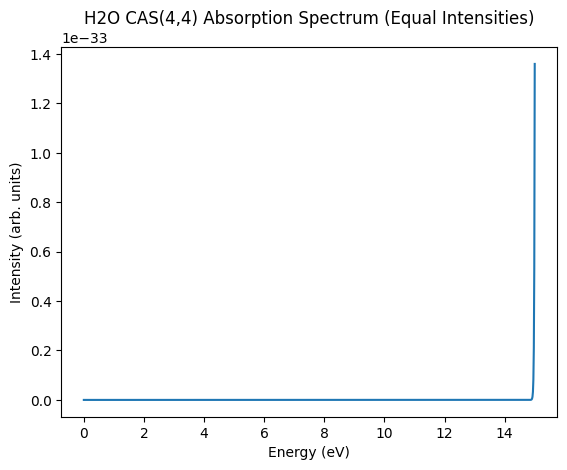

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, mp, mcscf

# -------------------------
# 1. Define molecule
# -------------------------
mol = gto.M(
    atom='''
    O 0 0 0
    H 0 -0.757 0.587
    H 0  0.757 0.587
    ''',
    basis='sto-3g'
)

# -------------------------
# 2. RHF
# -------------------------
mf = scf.RHF(mol).run()

# -------------------------
# 3. MP2 → Natural orbitals
# -------------------------
mp2 = mp.MP2(mf).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

print("Natural occupation numbers:")
print(noons)

# -------------------------
# 4. Define CAS(4,4)
# -------------------------
ncas = 4
nelecas = 4

# Pick most correlated orbitals (by occupation)
idx = np.argsort(-noons)
cas_list = idx[:ncas]

print("Selected CAS orbitals:", cas_list)

# -------------------------
# 5. CASCI (FCI in active space)
# -------------------------
mc = mcscf.CASCI(mf, ncas=ncas, nelecas=nelecas)

# Use natural orbitals
mc.mo_coeff = natorbs

# Tell CASCI which orbitals are active
mc.natorb = False
mc.sort_mo(cas_list)

# Compute multiple states
nroots = 5
mc.fcisolver.nroots = nroots

energies = mc.kernel()[0]

# -------------------------
# 6. Excitation energies
# -------------------------
hartree_to_ev = 27.2114
excitation_energies = (np.array(energies) - energies[0]) * hartree_to_ev

# Remove ground state
excitation_energies = excitation_energies[1:]

print("Excitation energies (eV):")
print(excitation_energies)

# -------------------------
# 7. Build spectrum (equal intensity)
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 15, 1000)
sigma = 0.2

spectrum = np.zeros_like(x)

for e in excitation_energies:
    spectrum += gaussian(x, e, sigma)

# -------------------------
# 8. Plot
# -------------------------
plt.plot(x, spectrum)
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (arb. units)")
plt.title("H2O CAS(4,4) Absorption Spectrum (Equal Intensities)")
plt.show()

In [8]:
excitation_energies

array([17.46098954, 17.51850291, 21.8554809 , 22.64949122])

converged SCF energy = -76.041381722386
E(RMP2) = -76.2632781238286  E_corr = -0.221896401442632
E(SCS-RMP2) = -76.2585175364314  E_corr = -0.217135814045415

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -76.0877613671282  E(CI) = -6.41048189367092  S^2 = 0.0000000
CASCI state   1  E = -75.3166178928779  E(CI) = -5.63933841942057  S^2 = 2.0000000
CASCI state   2  E = -75.3108105568726  E(CI) = -5.63353108341531  S^2 = 2.0000000
CASCI state   3  E = -75.2057259518019  E(CI) = -5.52844647834465  S^2 = 0.0000000
CASCI state   4  E = -75.1952031796099  E(CI) = -5.51792370615266  S^2 = 2.0000000
CASCI state   5  E = -75.1337218279830  E(CI) = -5.45644235452573  S^2 = 0.0000000
converged SCF energy = -76.4445445693653
Excited State energies (eV)
[ 6.90450391  8.35196436  9.08894119 10.24664793 10.51396765 11.09114976]


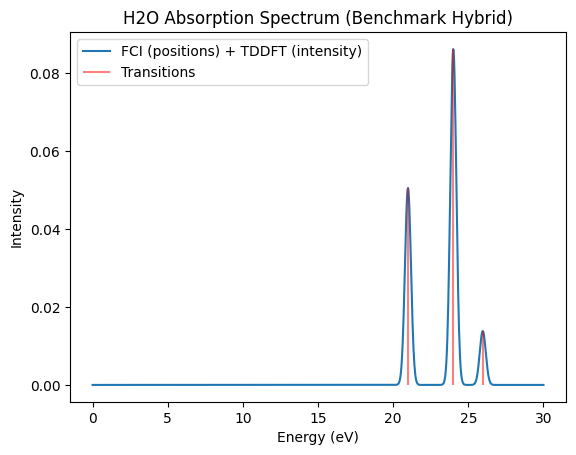

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, dft, tddft, mp, mcscf

hartree_to_ev = 27.2114

# -------------------------
# 1. Molecule
# -------------------------

basis = "aug-cc-pVDZ" #'6-31g'
mol = gto.M(
    atom='''
    O 0 0 0
    H 0 -0.757 0.587
    H 0  0.757 0.587
    ''',
    basis=basis   # better than STO-3G
)

# -------------------------
# 2. RHF (for CASCI)
# -------------------------
mf = scf.RHF(mol).run()

# MP2 → natural orbitals
mp2 = mp.MP2(mf).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

# -------------------------
# 3. CASCI (FCI benchmark)
# -------------------------
ncas = 4
nelecas = 4

# Select orbitals by occupation
idx = np.argsort(-noons)
# cas_list = idx[:ncas]
cas_list = idx[1:5]

mc = mcscf.CASCI(mf, ncas=ncas, nelecas=nelecas)
mc.mo_coeff = natorbs
mc.sort_mo(cas_list)

mc.fcisolver.nroots = 6
fci_energies = np.array(mc.kernel()[0])

fci_exc = (fci_energies - fci_energies[0]) * hartree_to_ev
fci_exc = fci_exc[1:]  # remove ground state

# -------------------------
# 4. TDDFT (intensities)
# -------------------------
mf_dft = dft.RKS(mol)
mf_dft.xc = "b3lyp"
mf_dft.kernel()

td = tddft.TDDFT(mf_dft)
td.nstates = 6
td.kernel()

td_energies = np.array(td.e) * hartree_to_ev
td_osc = td.oscillator_strength()

# -------------------------
# 5. Match FCI energies with TDDFT intensities
# -------------------------
# Simple approach: assume same ordering
n = min(len(ffci_excci_exc), len(td_osc))

energies = fci_exc[:n]
osc = td_osc[:n]

# -------------------------
# 6. Build spectrum
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 30, 1000)
sigma = 0.2

spectrum = np.zeros_like(x)

for e, f in zip(energies, osc):
    spectrum += f * gaussian(x, e, sigma)

# -------------------------
# 7. Plot
# -------------------------
plt.plot(x, spectrum, label="FCI (positions) + TDDFT (intensity)")

# Optional: show stick spectrum
plt.vlines(energies, 0, osc, color='red', alpha=0.5, label="Transitions")

plt.xlabel("Energy (eV)")
plt.ylabel("Intensity")
plt.title("H2O Absorption Spectrum (Benchmark Hybrid)")
plt.legend()
plt.show()

In [15]:
td_energies

array([ 6.90450746,  8.35196865,  9.08894586, 10.24665319, 10.51397305,
       11.09115546])

In [14]:
energies

array([20.98389354, 21.14191928, 24.0014185 , 24.28775786, 25.96075152])

In [2]:
# Define the molecule
molecule_name = "H2O"
active_space = "minimal"
molecule = MoleculeData.molecules[molecule_name]["coords"]

# Define the basis
basis = "sto-3g"

# Define the active space
num_active_orbs = MoleculeData.molecules[molecule_name][active_space]["num_active_orbs"]
num_active_alpha_electrons = MoleculeData.molecules[molecule_name][active_space]["num_active_alpha_electrons"]

In [72]:
molecule

[('O', 0.0, 0.0, 0.1035174918),
 ('H', 0.0, 0.7955612117, -0.4640237459),
 ('H', 0.0, -0.7955612117, -0.4640237459)]

In [14]:
num_active_alpha_electrons

2

In [24]:
natorbs[:num_active_orbs, :num_active_orbs].shape

(4, 4)

<bound method Mole.ao2mo of <pyscf.gto.mole.Mole object at 0x7f8960a45110>>

In [ ]:
# Get the HF ground state energy --> ground truth
# fci_gse, fci_vec = get_hf_gse_from_mol(molecule, basis)
# mol = gto.M(
# atom=molecule,
# basis=basis,
# unit='Angstrom',
# )

mol = gto.M(
    atom='''
    C  0.000000  1.397680  0.000000
    C  1.210380  0.698840  0.000000
    C  1.210380 -0.698840  0.000000
    C  0.000000 -1.397680  0.000000
    C -1.210380 -0.698840  0.000000
    C -1.210380  0.698840  0.000000
    H  0.000000  2.490000  0.000000
    H  2.160000  1.245000  0.000000
    H  2.160000 -1.245000  0.000000
    H  0.000000 -2.490000  0.000000
    H -2.160000 -1.245000  0.000000
    H -2.160000  1.245000  0.000000
    ''',
    basis='sto-3g', # Small basis for speed in example
    symmetry=True,
    verbose=0
)


hf_energy = mol.RHF().run()
moller_plesset = mp.MP2(hf_energy).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(moller_plesset)
cisolver = fci.FCI(mol, natorbs)
fci_gse, fci_vec = cisolver.kernel()
print(f"E(FCI) = {fci_gse}")

In [33]:
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.make_dm1234('FCI4pdm_kern_sf', fci_vec, fci_vec, 7, 4)
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.reorder_dm1234(fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4) # comes in a different orientation.
h_mo = one_electron_integral_transform(natorbs, mol.intor("int1e_kin") + mol.intor("int1e_nuc"))
g_mo = two_electron_integral_transform(natorbs, mol.intor("int2e"))#

In [ ]:
g_mo.shape

(7, 7, 7, 7)

In [16]:
natorbs.shape

(7, 7)

In [37]:
dmdm = DMDM(
        h_mo,
        g_mo,
        0,
        7,
        0,
        4,
        fci_rdm1,
        rdm2=fci_rdm2,
        rdm3=fci_rdm3,
        rdm4=fci_rdm4,
        # print_level=3,
    )

In [38]:
x, y, z = mol.intor('int1e_r', comp=3)
MO_DM = [one_electron_integral_transform(natorbs, x), one_electron_integral_transform(natorbs, y), one_electron_integral_transform(natorbs, z)]

exc_energies = dmdm.get_excitation_energies()
osc_strengths = dmdm.get_oscillator_strength(MO_DM)

print("Excitation energies (a.u.): ", exc_energies)
print("Oscillator strengths: ", osc_strengths)

idx, max(abs(grad active)): 84 3.4436396109886784
Smallest Hessian eigenvalue: (-1.464747897097241+0j)
Smallest diagonal element in the metric: 0.9702708080204958
Excitation energies (a.u.):  [4.06572876e-02 5.81948756e-02 1.93613228e-01 2.31197224e-01
 2.98162371e-01 6.25489586e-01 7.20181826e-01 7.85338278e-01
 9.15816264e-01 9.38135822e-01 1.48489833e+00 1.49685225e+00
 1.53127240e+00 1.56488404e+00 1.57450177e+00 1.58338814e+00
 1.58903616e+00 3.49154943e+00 3.99796347e+00 4.00190997e+00
 1.93688498e+01 1.99707831e+01 2.01111455e+01 2.01349009e+01
 2.01696337e+01 2.02547754e+01 2.05930039e+01 2.06982474e+01
 2.07191940e+01 2.07449476e+01 2.08794595e+01 2.10000271e+01
 2.20516522e+01 2.20627589e+01 2.22897435e+01 2.22961020e+01
 2.26504981e+01 2.26574902e+01 2.26967911e+01 2.27090795e+01
 2.27863018e+01 2.27881396e+01 2.28345933e+01 2.28400707e+01
 2.28648004e+01 2.28817441e+01 2.49392238e+01 2.50002599e+01
 2.55168736e+01 2.55212471e+01 4.35703524e+01 4.42957071e+01
 4.44078151e+01

In [60]:
exc_energies.shape

(65,)

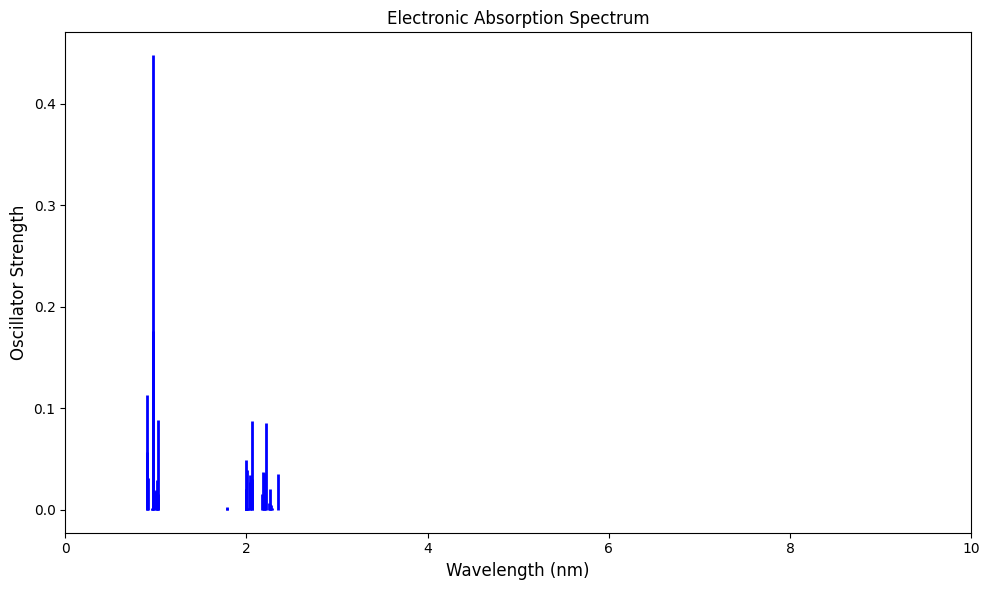

In [71]:
# Convert Hartree to eV (1 Hartree = 27.2114 eV)
hartree_to_ev = 27.2114
energies_ev = np.array(exc_energies) * hartree_to_ev

# Convert to wavelength (nm) for UV-Vis spectra
# E(eV) = 1239.84 / λ(nm)
wavelengths_nm = 1239.84 / energies_ev

# Create stick spectrum
plt.figure(figsize=(10, 6))
for i, (wl, osc) in enumerate(zip(wavelengths_nm, osc_strengths)):
    plt.vlines(wl, 0, osc, colors='blue', linewidth=2)
    # plt.text(wl, osc*1.1, f'{i+1}', ha='center', fontsize=9)

plt.xlim(0, 10)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Oscillator Strength', fontsize=12)
plt.title('Electronic Absorption Spectrum')
plt.tight_layout()
plt.show()

In [46]:
def plot_spectrum(energies_ev, osc_strengths, sigma_eV=0.3, xlim_nm=(150, 800), title="UV-Vis Spectrum (HF/CIS)"):
    wl_plot = np.linspace(xlim_nm[0], xlim_nm[1], 1000)
    energy_plot = ev_to_wl / wl_plot
    
    spectrum_intensity = np.zeros_like(wl_plot)
    
    for e_ev, f in zip(energies_ev, osc_strengths):
        gaussian = np.exp(-((energy_plot - e_ev)**2) / (2 * sigma_eV**2))
        spectrum_intensity += f * gaussian
    
    max_val = np.max(spectrum_intensity)
    if max_val > 0:
        spectrum_intensity /= max_val
    
    plt.figure(figsize=(10, 6))
    plt.plot(wl_plot, spectrum_intensity, color='blue', linewidth=2, label='Simulated')
    
    for wl, f in zip(wavelengths_nm, osc_strengths):
        if f > 0.01:
            plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Relative Intensity (a.u.)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(xlim_nm[1], xlim_nm[0])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    filename = 'water_spectrum_hf.png'
    plt.savefig(filename, dpi=300)
    print(f"\nSpectrum saved to: {filename}")
    plt.show()

In [ ]:
# Convert units
hartree_to_ev = 27.2114
ev_to_wl = 1239.84

energies_ev = exc_energies_hartree * hartree_to_ev
wavelengths_nm = ev_to_wl / energies_ev

(7, 7)

In [ ]:
plot_spectrum(energies_ev, osc_strengths, sigma_eV=0.3)